In [1]:
# Phase 1: Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Phase 2: Load Dataset

# Load the dataset
df = pd.read_excel("../datasets/Mall Customers.xlsx")

print("Dataset Loaded Successfully!\n")

# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display dataset dimensions
print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

In [ ]:
# Phase 3.1: Dataset Overview

print("Dataset Information:\n")
df.info()

print("\nData Types:\n")
display(df.dtypes)

print("\nDataset Shape:")
print(df.shape)

# Phase 3.2: Missing Values & Duplicate Rows
print("Missing Values:\n")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Phase 3.3: Statistical Summary
print("Numerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include="object"))

# Phase 3.4: Data Visualization

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [12]:
# Phase 4: Data Preprocessing
# Create a copy of the dataset
df_processed = df.copy()

# Remove unnecessary columns
columns_to_drop = [
    "CustomerID",
    "Gender",
    "Age",
    "Education",
    "Marital Status"
]

df_processed.drop(columns=columns_to_drop, inplace=True)

print("Unnecessary columns removed successfully!")

display(df_processed.head())

print("\nDataset Shape:")
print(df_processed.shape)

print("\nMissing Values:")
print(df_processed.isnull().sum())

Unnecessary columns removed successfully!


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40



Dataset Shape:
(200, 2)

Missing Values:
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
# Phase 5: Feature Scaling
# Create a StandardScaler object
scaler = StandardScaler()
# Scale the selected features
X_scaled = scaler.fit_transform(df_processed)
print("Feature Scaling Completed Successfully!")
# Convert scaled data into a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_processed.columns
)
display(X_scaled.head())
print("Mean of Scaled Features:")
print(X_scaled.mean())

print("\nStandard Deviation of Scaled Features:")
print(X_scaled.std())

WCSS values calculated successfully!


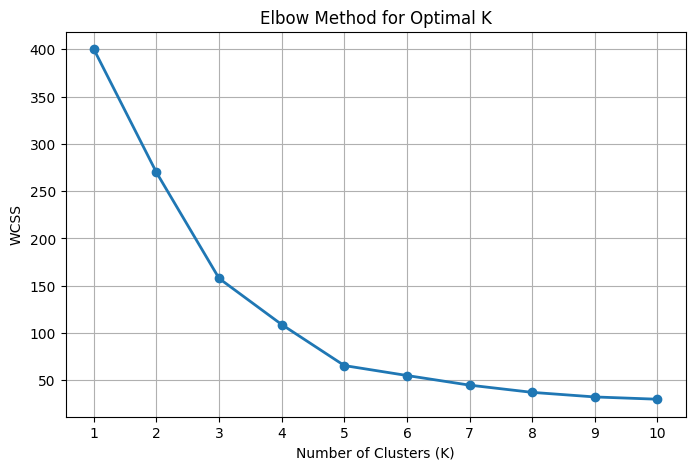

K = 1  -->  WCSS = 400.00
K = 2  -->  WCSS = 269.69
K = 3  -->  WCSS = 157.70
K = 4  -->  WCSS = 108.92
K = 5  -->  WCSS = 65.57
K = 6  -->  WCSS = 55.06
K = 7  -->  WCSS = 44.86
K = 8  -->  WCSS = 37.23
K = 9  -->  WCSS = 32.39
K = 10  -->  WCSS = 29.98


In [14]:
# Phase 6: Find Optimal Number of Clusters
# Store WCSS values
wcss = []

# Calculate WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print("WCSS values calculated successfully!")

# Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(
    range(1, 11),
    wcss,
    marker="o",
    linewidth=2
)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# Display WCSS Values
for k, value in enumerate(wcss, start=1):
    print(f"K = {k}  -->  WCSS = {value:.2f}")

In [15]:
# Phase 7: Train the K-Means Model
# Create the K-Means model
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)
# Fit the model and predict clusters
clusters = kmeans.fit_predict(X_scaled)
print("K-Means Model Trained Successfully!")
# Add Cluster Labels
# Add cluster labels to the processed dataset
df_processed["Cluster"] = clusters
print("Cluster Labels Added Successfully!")
display(df_processed.head())
# Customers in Each Cluster
print("Customers in Each Cluster:\n")
print(df_processed["Cluster"].value_counts().sort_index())
# Cluster Centers (Original Scale)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(
    centers,
    columns=df_processed.columns[:-1]  # Exclude "Cluster"
)
print("Cluster Centers:")
display(centers_df)

K-Means Model Trained Successfully!
Cluster Labels Added Successfully!


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


Customers in Each Cluster:

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
Cluster Centers:


,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043
